<h1>Text-To-Image Generation using Stable Diffusion and Diffusers</h1>

In [23]:
! pip install diffusers transformers gradio accelerate

In [24]:
from diffusers import StableDiffusionPipeline
import torch
from matplotlib import pyplot as plt

In [25]:
! pip show torch

Name: torch
Version: 2.6.0+cu124
Summary: Tensors and Dynamic neural networks in Python with strong GPU acceleration
Home-page: https://pytorch.org/
Author: PyTorch Team
Author-email: packages@pytorch.org
License: BSD-3-Clause
Location: /usr/local/lib/python3.11/dist-packages
Requires: filelock, fsspec, jinja2, networkx, nvidia-cublas-cu12, nvidia-cuda-cupti-cu12, nvidia-cuda-nvrtc-cu12, nvidia-cuda-runtime-cu12, nvidia-cudnn-cu12, nvidia-cufft-cu12, nvidia-curand-cu12, nvidia-cusolver-cu12, nvidia-cusparse-cu12, nvidia-cusparselt-cu12, nvidia-nccl-cu12, nvidia-nvjitlink-cu12, nvidia-nvtx-cu12, sympy, triton, typing-extensions
Required-by: accelerate, fastai, peft, sentence-transformers, timm, torchaudio, torchdata, torchvision


In [26]:
model_id1 = "dreamlike-art/dreamlike-photoreal-2.0"
model_id2 = "stabilityai/stable-diffusion-2-1"

pipe = StableDiffusionPipeline.from_pretrained(model_id2, torch_dtype=torch.float16, use_safetensors=True)
pipe = pipe.to("cuda")

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

In [27]:
prompt = """dreamlikeart, a grungy young woman with long rainbow-colored hair, traveling between dimensions in a dynamic pose.
She looks joyful and expressive, with a dainty figure and soft lighting.
Her straight hair flows down naturally. She wears a torn kawaii-style shirt and oversized baggy jeans.
Extreme bokeh background enhances the dreamy atmosphere."""


In [28]:
image = pipe(prompt).images[0]

  0%|          | 0/50 [00:00<?, ?it/s]

[PROMPT]:  dreamlikeart, a grungy young woman with long rainbow-colored hair, traveling between dimensions in a dynamic pose. 
She looks joyful and expressive, with a dainty figure and soft lighting. 
Her straight hair flows down naturally. She wears a torn kawaii-style shirt and oversized baggy jeans. 
Extreme bokeh background enhances the dreamy atmosphere.


(np.float64(0.0), np.float64(1.0), np.float64(0.0), np.float64(1.0))

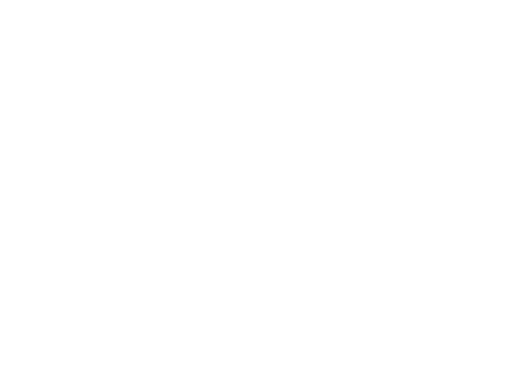

In [29]:
print("[PROMPT]: ", prompt)
plt.show(image)
plt.axis('off')

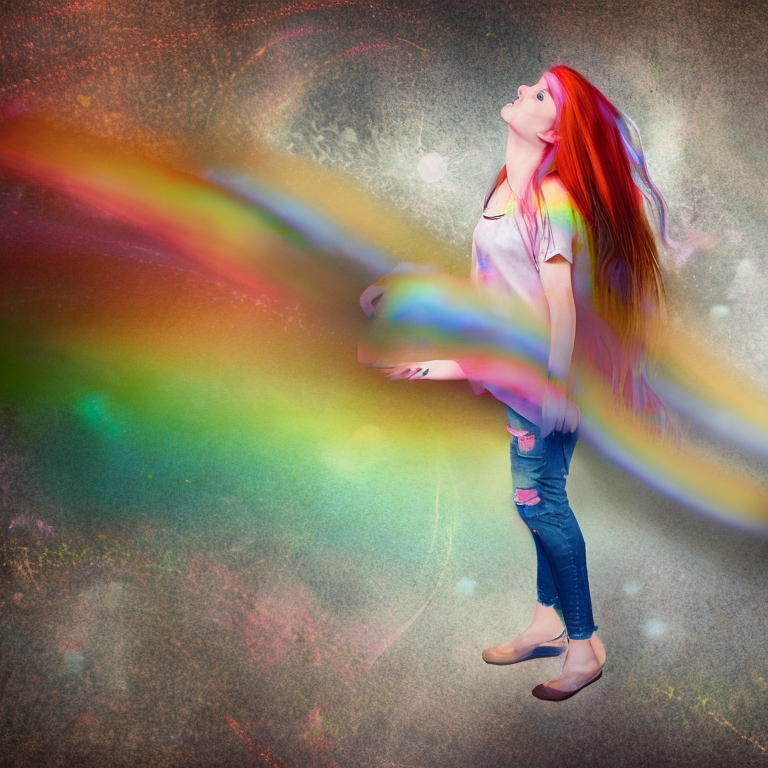

In [30]:
image

In [31]:
prompt2 = """A girl is sittig on a chair & She is accompanied by her tiger. Make sure to keep it cinematic and color
"""

[PROMPT]:  A girl is sittig on a chair & She is accompanied by her tiger. Make sure to keep it cinematic and color



(np.float64(-0.5), np.float64(767.5), np.float64(767.5), np.float64(-0.5))

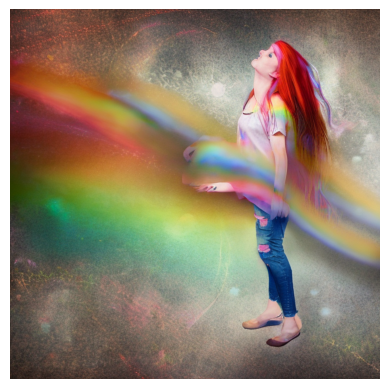

In [32]:
print("[PROMPT]: ", prompt2)
plt.imshow(image)
plt.axis('off' )

In [33]:
def generate_image(pipe, prompt, params):
    image = pipe(prompt, **params).images

    num_images = len(image)
    if num_images > 1:
      fig, ax = plt.subplots(nrows=1, ncols= num_images)
      for i in range(num_images):
        ax[i].imshow(image[1]);
        ax[i].axis('off');
    else:
      fig = plt.figure()
      plt.imshow(image[0]);
      plt.axis('off');
    plt.tight_layout()

In [34]:
prompt = "dreamlike, beautiful girl playing the festival of colors, draped in traditional Indian attire, throwing co"
params={}

  0%|          | 0/50 [00:00<?, ?it/s]

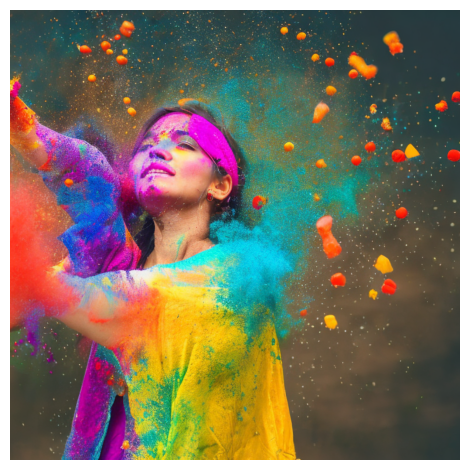

In [35]:
generate_image(pipe, prompt, params)

  0%|          | 0/100 [00:00<?, ?it/s]

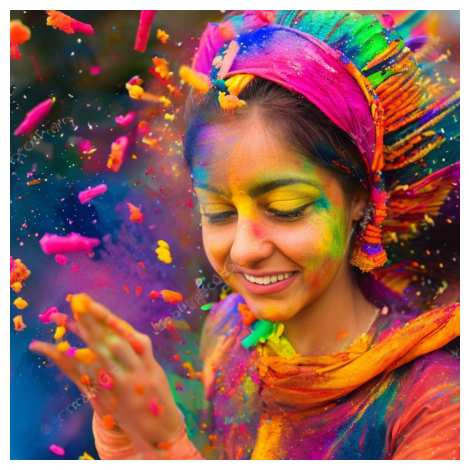

In [36]:
params = {'num_inference_steps': 100}
generate_image(pipe, prompt, params)

  0%|          | 0/100 [00:00<?, ?it/s]

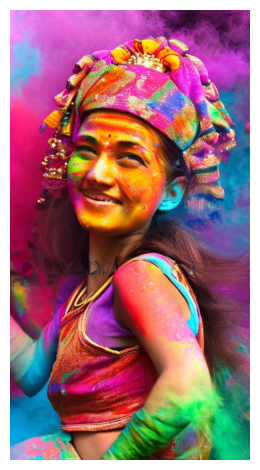

In [37]:
params = {'num_inference_steps': 100, 'width': 512, 'height': int(1.5*640)}
generate_image(pipe, prompt, params)

  0%|          | 0/100 [00:00<?, ?it/s]

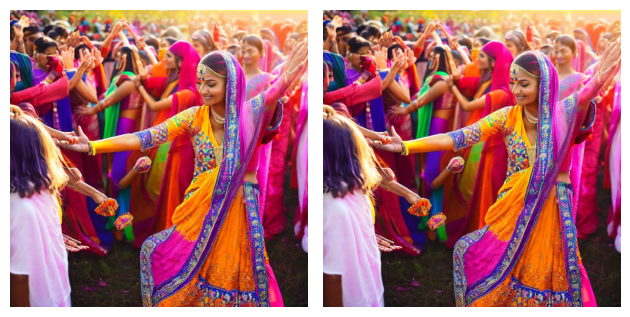

In [38]:
params = {'num_inference_steps': 100, 'num_images_per_prompt': 2, 'negative_prompt': 'ugly, disfigured, low quality'}
generate_image(pipe, prompt, params)